In [2]:
# -*- coding: utf-8 -*-
"""
从基础BERT提取SMILES词嵌入 + t-SNE可视化（不使用微调权重）
"""
import os
import random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizerFast, BertModel
from sklearn.manifold import TSNE
from sklearn.metrics import davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns

# ========= 可调参数 =========
EXCEL_PATH = "./invertebrates_LC50_unique.xlsx"
SMILES_COL = "SMILES_Canonical_RDKit"
MGPERL_COL = "mgperL"

CHECKPOINT = "../models/base_bert"   # 你的基础BERT（未微调）路径
MAX_LEN = 128
BATCH_SIZE = 256
NUM_WORKERS = 0   # Windows 建议0，Linux可设>=2
SEED = 42
PERPLEXITY = 30
N_ITER = 1000
POOLING = "cls"   # 可选 "cls" 或 "mean"
SAVE_DIR = "./k_folds_model/embeddings_base"
os.makedirs(SAVE_DIR, exist_ok=True)

# ========= 随机种子 =========
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ========= 数据读取 =========
df = pd.read_excel(EXCEL_PATH)
df = df.dropna(subset=[SMILES_COL, MGPERL_COL]).copy()
smiles_list = df[SMILES_COL].astype(str).tolist()
mgperL = df[MGPERL_COL].astype(float).values
mgperL = np.log1p(mgperL)  # 与你现有流程保持一致

# 生成离散标签（和你给的阈值一致）
def generate_label(mg):
    if mg < np.log1p(1):
        return 0  # high
    elif np.log1p(1) <= mg < np.log1p(10):
        return 1  # mid
    elif np.log1p(10) <= mg < np.log1p(100):
        return 2  # mid
    else:
        return 3  # low

classification_labels = np.array([generate_label(v) for v in mgperL], dtype=int)

# ========= 基础BERT & Tokenizer =========
tokenizer = BertTokenizerFast.from_pretrained(CHECKPOINT)
bert = BertModel.from_pretrained(CHECKPOINT).to(device)
bert.eval()

# ========= Dataset / DataLoader =========
class SMILESDataset(Dataset):
    def __init__(self, smiles, max_len=128):
        self.smiles = smiles
        self.max_len = max_len

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        s = self.smiles[idx]
        enc = tokenizer(
            s,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )
        # 去掉 batch 维
        enc = {k: v.squeeze(0) for k, v in enc.items()}
        return enc

def collate_fn(batch):
    # 将单条样本的 dict 合并为 batch 的 dict
    keys = batch[0].keys()
    out = {k: torch.stack([b[k] for b in batch], dim=0) for k in keys}
    return out

loader = DataLoader(
    SMILESDataset(smiles_list, MAX_LEN),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
    collate_fn=collate_fn
)

# ========= 提取基础BERT词嵌入 =========
@torch.inference_mode()
def extract_embeddings(model, data_loader, pooling="cls"):
    all_embeds = []
    for batch in data_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)  # last_hidden_state: [B, L, H]
        last_hidden = outputs.last_hidden_state

        if pooling.lower() == "cls":
            emb = last_hidden[:, 0, :]  # [B, H]
        elif pooling.lower() == "mean":
            mask = batch["attention_mask"].unsqueeze(-1)  # [B, L, 1]
            summed = (last_hidden * mask).sum(dim=1)
            lengths = mask.sum(dim=1).clamp(min=1e-9)
            emb = summed / lengths
        else:
            raise ValueError("POOLING 只支持 'cls' 或 'mean'")

        all_embeds.append(emb.detach().cpu().numpy())

    return np.vstack(all_embeds)

embeddings = extract_embeddings(bert, loader, pooling=POOLING)
print("Embeddings shape:", embeddings.shape)



# ========= t-SNE =========
tsne = TSNE(
    n_components=2,
    random_state=SEED,
    perplexity=PERPLEXITY,
    n_iter=N_ITER,
    init="pca",
    metric="euclidean"
)
tsne_result = tsne.fit_transform(embeddings)

dbi_tsne = davies_bouldin_score(tsne_result, classification_labels)
print(f"Davies-Bouldin index (t-SNE space): {dbi_tsne:.3f}")




Device: cuda
Embeddings shape: (4187, 768)


/root/miniconda3/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Davies-Bouldin index (t-SNE space): 20.550


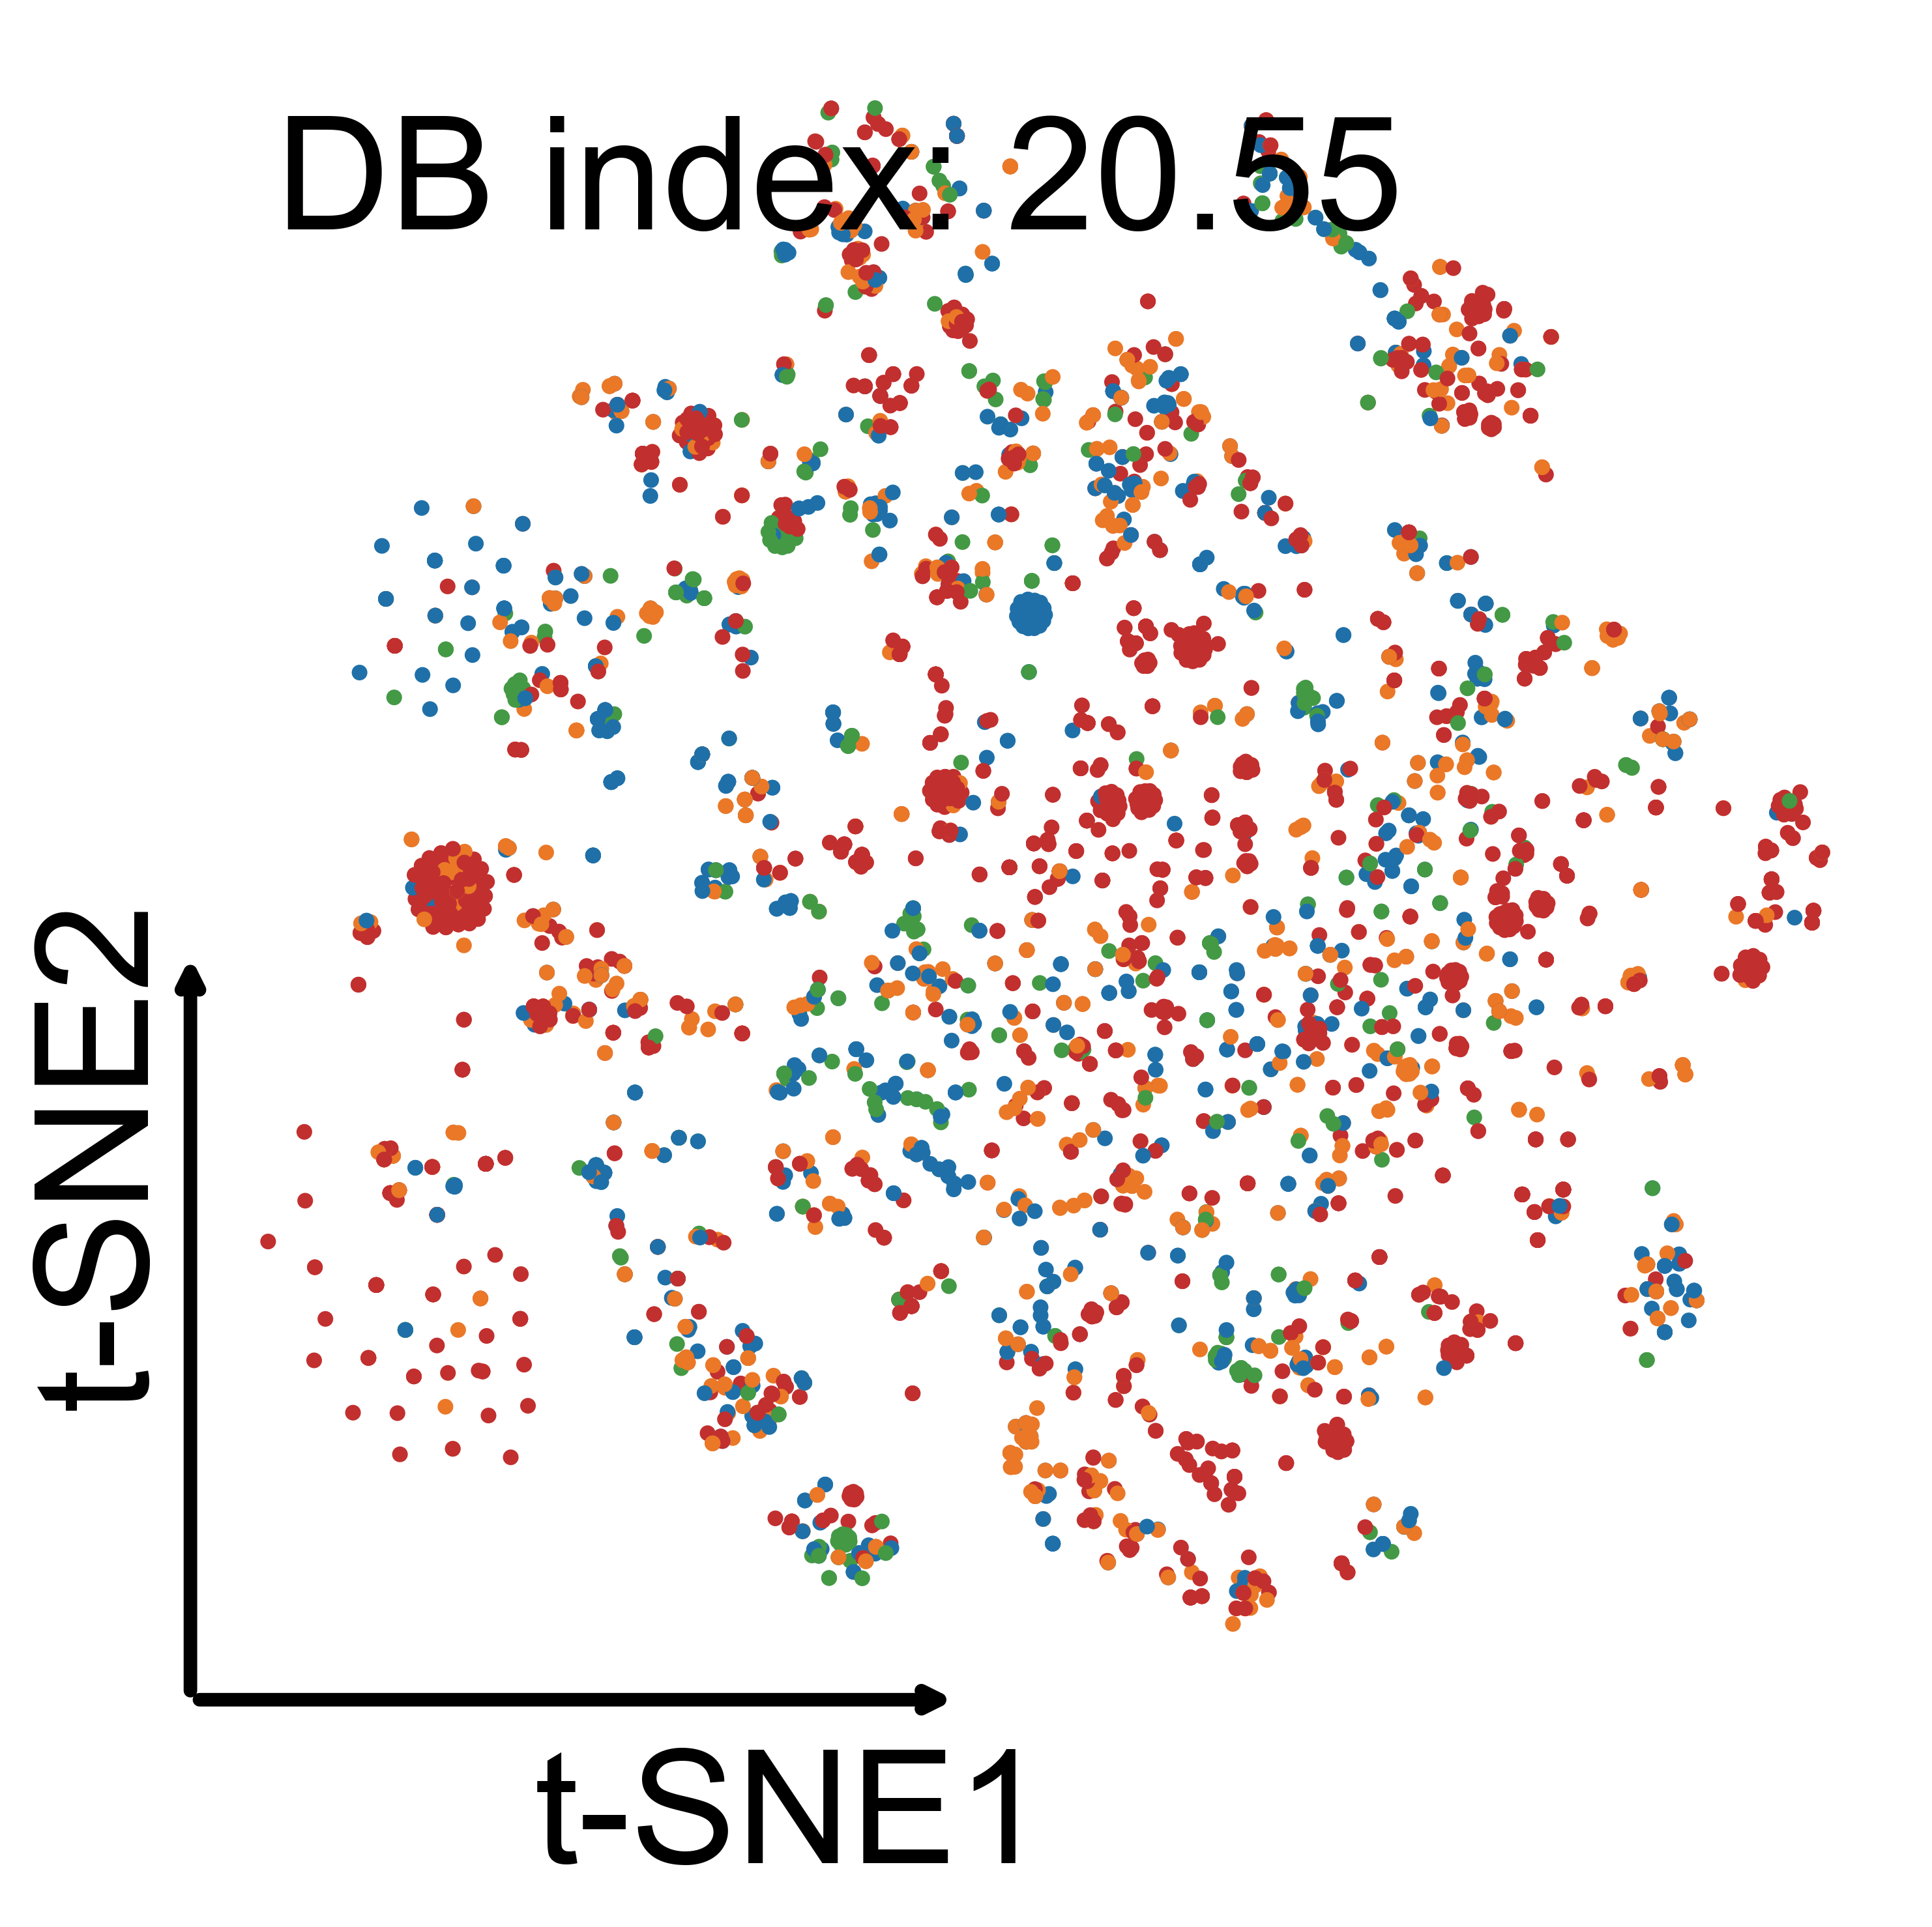

In [3]:
# ====== 画图（使用你的 Arial 字体 & 配色）======
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.font_manager as fm

# 你的字体与配色（上一行要换行，别和字典粘在一起）
arial_font = fm.FontProperties(fname="../Arial/arial.ttf", size=35)
custom_palette = {
    0: "#c22f2f",  # 红
    1: "#ea7827",  # 黄橙
    2: "#1f70a9",  # 蓝
    3: "#449945",  # 绿
}

plt.figure(figsize=(6, 6), dpi=500)

# 明确设为离散分类，确保 color 映射按 0/1/2/3
hue_cats = pd.Categorical(classification_labels, categories=[0, 1, 2, 3], ordered=True)

sns.scatterplot(
    x=tsne_result[:, 0],
    y=tsne_result[:, 1],
    hue=hue_cats,
    palette=custom_palette,   # 使用字典映射
    s=12,
    edgecolor=None,
    linewidth=0,
    legend=False              # 按你之前风格，去掉图例
)

# DB index 标注（使用你的 Arial 字体）
plt.text(
    0.05, 0.95,
    f"DB index: {dbi_tsne:.2f}",
    transform=plt.gca().transAxes,
    fontproperties=arial_font,
    ha="left", va="top"
)

# 去掉坐标轴与边框
plt.axis('off')

# 轴向箭头（与之前风格一致）
ax = plt.gca()
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
origin = (x_min, y_min)
arrow_props = dict(arrowstyle='->', linewidth=3, color='black', shrinkA=2, shrinkB=20)

# t-SNE1 箭头与文字
arrow_x_end = x_min + (x_max - x_min) * 0.5
ax.annotate("", xy=(arrow_x_end, y_min), xytext=origin, arrowprops=arrow_props)
ax.text(
    arrow_x_end, y_min - (y_max - y_min) * 0.03,
    "t-SNE1",
    fontproperties=arial_font,
    ha='right', va='top'
)

# t-SNE2 箭头与文字
arrow_y_end = y_min + (y_max - y_min) * 0.5
ax.annotate("", xy=(x_min, arrow_y_end), xytext=origin, arrowprops=arrow_props)
ax.text(
    x_min - (x_max - x_min) * 0.05,
    arrow_y_end - (y_max - y_min) * 0.02,
    "t-SNE2",
    fontproperties=arial_font,
    ha='center', va='top', rotation=90
)

plt.tight_layout()
out_png = os.path.join(SAVE_DIR, f"tsne_base_cls_custom_font_palette.png")
plt.show()